PART 1 — EXPLORATORY DATA ANALYSIS (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split




In [2]:
# ── Load Data ──────────────────────────────────────────────
df = pd.read_csv('../data/house_prices.csv')
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
# ── Basic Overview ─────────────────────────────────────────
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:\n", df.describe())

Shape: (13320, 9)

Column Names:
 ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

Data Types:
 area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

First 5 Rows:
               area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3

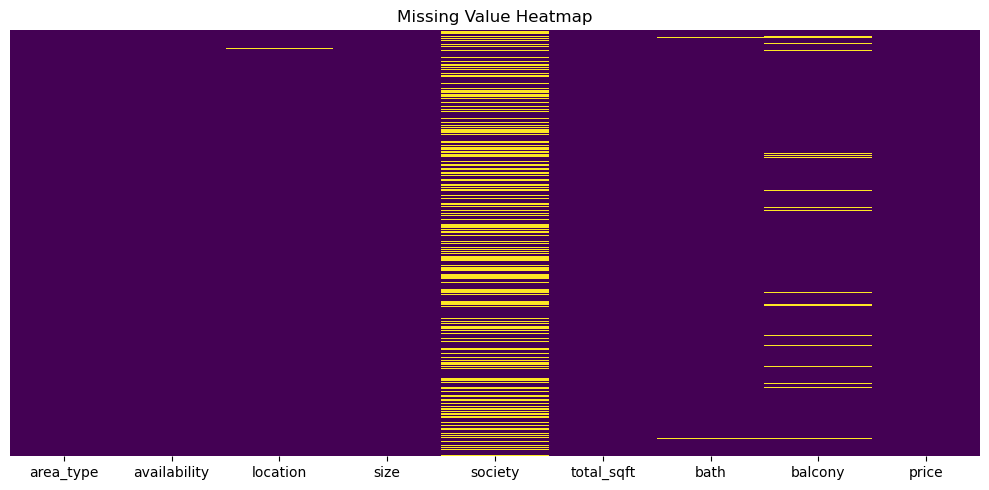

In [4]:
#GRAPH 1 — Missing Value Heatmap

import os
os.makedirs('plots', exist_ok=True)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.savefig('plots/missing_values.png')
plt.show()

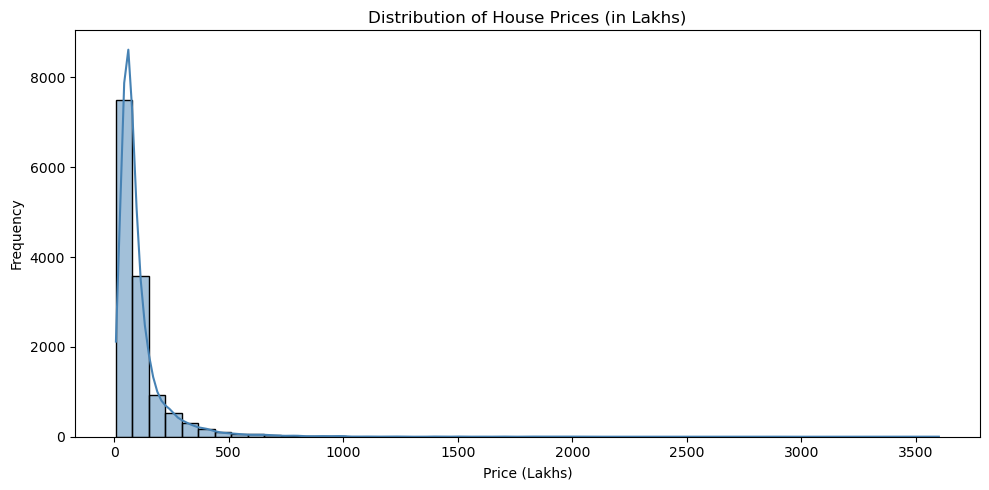

Skewness: 8.064468821273252


In [5]:
#GRAPH 2 — Price Distribution

import os
os.makedirs('plots', exist_ok=True)

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices (in Lakhs)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/price_distribution.png')
plt.show()

print("Skewness:", df['price'].skew())

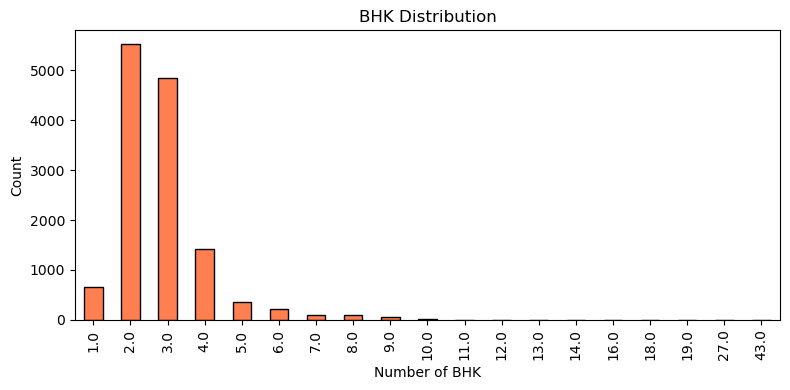

In [6]:
#GRAPH 3 — BHK Distribution

# First extract BHK from size column
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(8, 4))
df['bhk'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title('BHK Distribution')
plt.xlabel('Number of BHK')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/bhk_distribution.png')
plt.show()

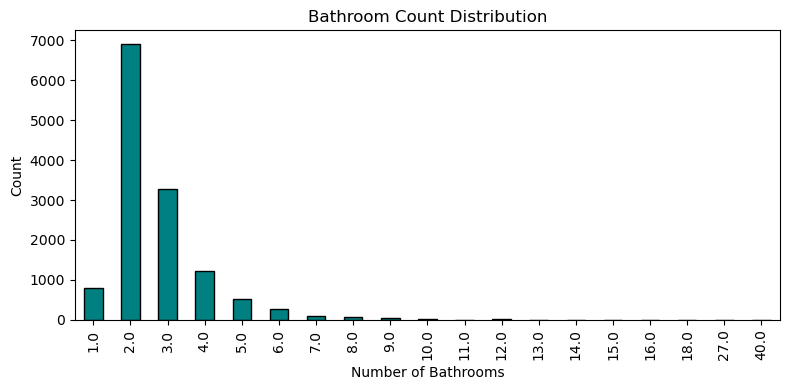

In [7]:
#GRAPH 4 — Bathroom Distribution

plt.figure(figsize=(8, 4))
df['bath'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Bathroom Count Distribution')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/bath_distribution.png')
plt.show()

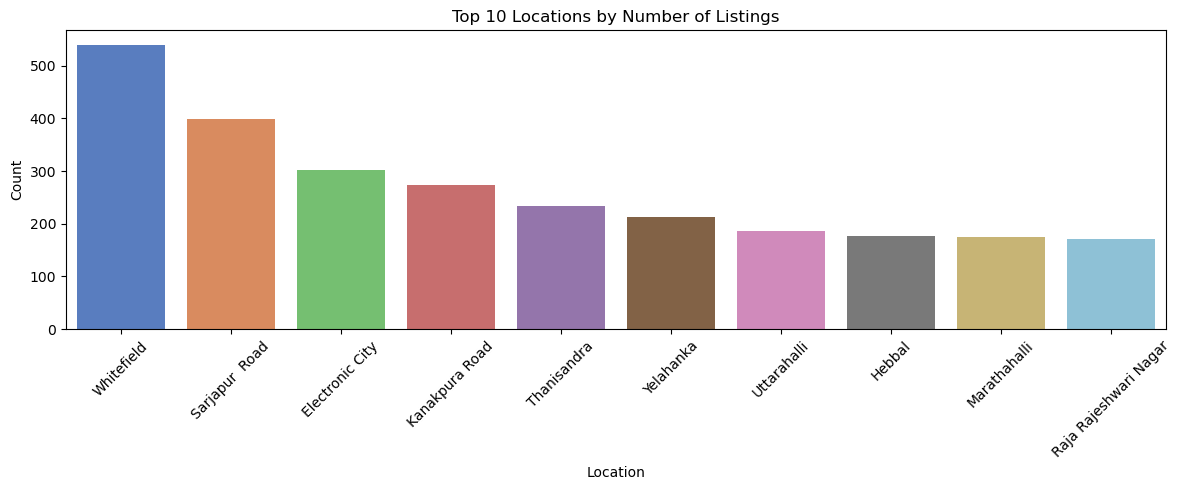

In [8]:
#GRAPH 5 — Top 10 Locations by Listing Count
plt.figure(figsize=(12, 5))
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.index, y=top_locations.values, hue=top_locations.index, palette='muted', legend=False)
plt.title('Top 10 Locations by Number of Listings')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/top_locations.png')
plt.show()

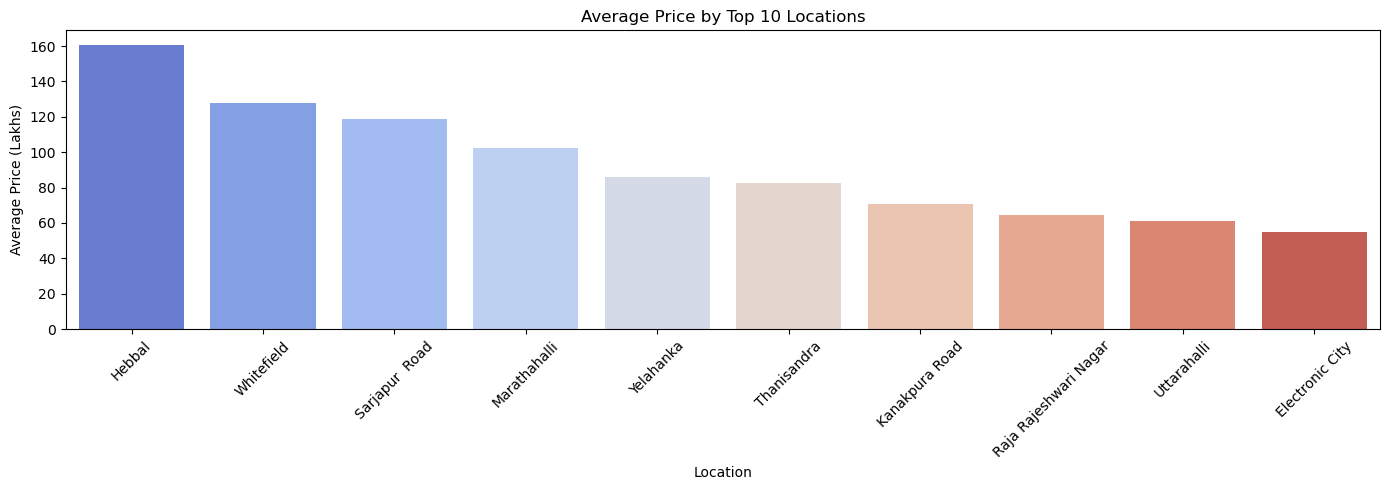

In [9]:
#GRAPH 6 — Average Price by Top Locations
plt.figure(figsize=(14, 5))
top10_locs = df['location'].value_counts().head(10).index
avg_price = df[df['location'].isin(top10_locs)].groupby('location')['price'].mean().sort_values(ascending=False)
sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    hue=avg_price.index,
    palette='coolwarm',
    legend=False
)
plt.title('Average Price by Top 10 Locations')
plt.xlabel('Location')
plt.ylabel('Average Price (Lakhs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/avg_price_location.png')
plt.show()

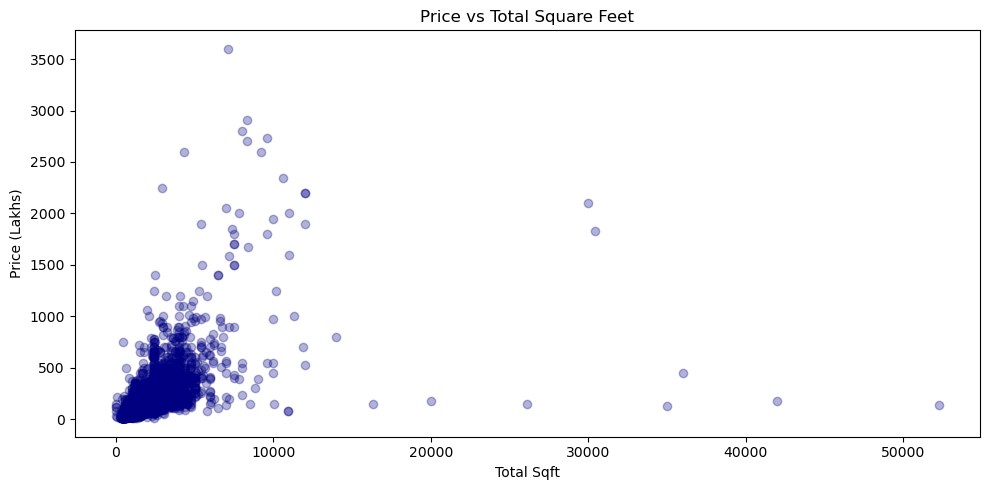

In [10]:
#GRAPH 7 — Price vs Total Sqft (Scatter)
# Use only clean numeric sqft for now
df_temp = df[pd.to_numeric(df['total_sqft'], errors='coerce').notnull()].copy()
df_temp['total_sqft'] = pd.to_numeric(df_temp['total_sqft'], errors='coerce')

plt.figure(figsize=(10, 5))
plt.scatter(df_temp['total_sqft'], df_temp['price'], alpha=0.3, color='navy')
plt.title('Price vs Total Square Feet')
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.tight_layout()
plt.savefig('plots/price_vs_sqft.png')
plt.show()

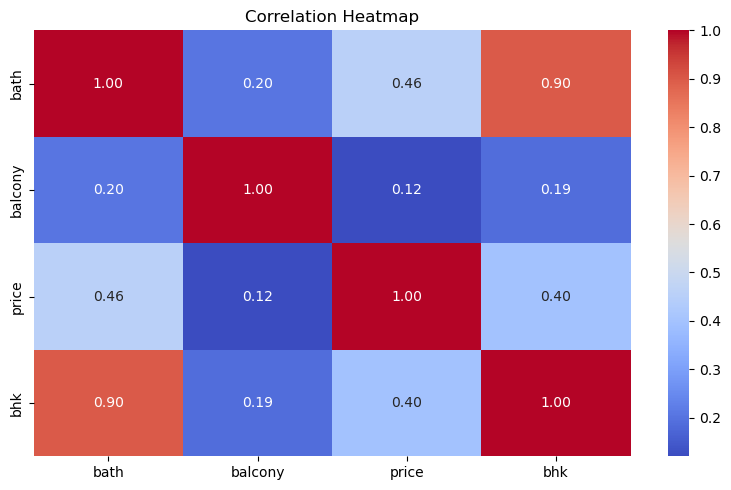

In [11]:
#GRAPH 8 — Correlation Heatmap
plt.figure(figsize=(8, 5))
numeric_df = df[['bath', 'balcony', 'price']].copy()
numeric_df['bhk'] = df['bhk']
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png')
plt.show()

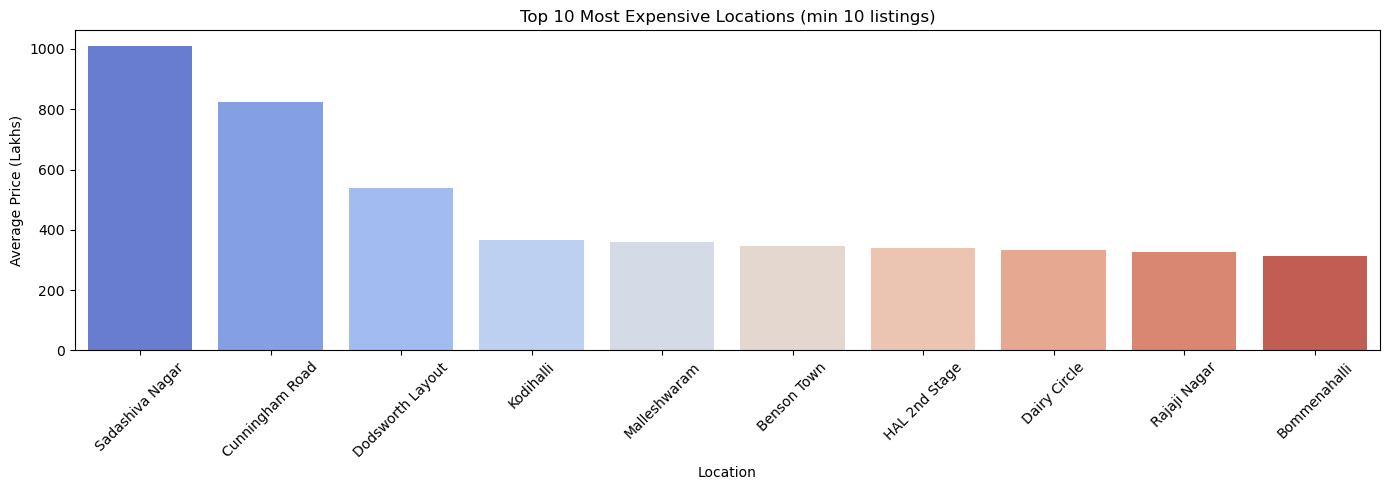

In [12]:
#Graph 9 -  Most expensive locations (minimum 10 listings to be fair)
plt.figure(figsize=(14, 5))
expensive = df.groupby('location').filter(lambda x: len(x) >= 10)
avg_price = expensive.groupby('location')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_price.index, y=avg_price.values,hue=avg_price.index, palette='coolwarm',legend=False)
plt.title('Top 10 Most Expensive Locations (min 10 listings)')
plt.xlabel('Location')
plt.ylabel('Average Price (Lakhs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/most_expensiveLocation.png')
plt.show() 

PART 2 — DATA CLEANING


In [13]:
df.drop(columns=['area_type', 'availability', 'society', 'balcony'], inplace=True)


In [14]:
print("After dropping columns:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())


After dropping columns: (13320, 6)

Column Names:
 ['location', 'size', 'total_sqft', 'bath', 'price', 'bhk']


In [15]:
# ── STEP 2: Drop Rows with Missing Values ──────────────────
df.dropna(inplace=True)
print("After dropping nulls:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


After dropping nulls: (13246, 6)

Missing Values:
 location      0
size          0
total_sqft    0
bath          0
price         0
bhk           0
dtype: int64


In [16]:
# ── STEP 3: Extract BHK from Size Column ───────────────────
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(int)
df.drop(columns=['size'], inplace=True)

print(df['bhk'].value_counts())

bhk
2     5527
3     4832
4     1395
1      649
5      353
6      221
7      100
8       89
9       54
10      14
11       4
27       1
19       1
16       1
43       1
14       1
12       1
13       1
18       1
Name: count, dtype: int64


In [17]:
# ── STEP 4: Clean total_sqft Column ────────────────────────
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        # Range like "1000-1500" → take average
        try:
            return (float(tokens[0]) + float(tokens[1])) / 2
        except:
            return None
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)
df.dropna(subset=['total_sqft'], inplace=True)

print("After sqft cleaning:", df.shape)

After sqft cleaning: (13200, 5)


In [18]:
# ── STEP 6: Reduce Location Cardinality ────────────────────
df['location'] = df['location'].str.strip()
location_counts = df['location'].value_counts()

# Any location with fewer than 10 listings → label as 'other'
rare_locations = location_counts[location_counts < 10].index
df['location'] = df['location'].apply(
    lambda x: 'other' if x in rare_locations else x
)

print("Unique locations after reduction:", df['location'].nunique())

Unique locations after reduction: 255


PART 3 — OUTLIER HANDLING


In [19]:
print(df.columns.tolist())


['location', 'total_sqft', 'bath', 'price', 'bhk']


In [20]:
outliers = df[df['total_sqft'] / df['bhk'] < 300]
print(outliers.shape)
outliers.head()

(744, 5)


,location,total_sqft,bath,price,bhk
9,other,1020.0,6.0,370.0,6
45,HSR Layout,600.0,9.0,200.0,8
58,Murugeshpalya,1407.0,4.0,150.0,6
68,Devarachikkanahalli,1350.0,7.0,85.0,8
70,other,500.0,3.0,100.0,3


In [21]:
# ── STEP 7: Remove Outliers Using Business Logic ───────────

# Rule 1: Minimum sqft per BHK should be 300 sqft
# (A 2 BHK at 400 sqft total is physically impossible)
df = df[df['total_sqft'] / df['bhk'] >= 300]
print("After sqft/bhk rule:", df.shape)

After sqft/bhk rule: (12456, 5)


In [22]:
print(df[['total_sqft', 'price']].head())
print(df.dtypes)

   total_sqft   price
0      1056.0   39.07
1      2600.0  120.00
2      1440.0   62.00
3      1521.0   95.00
4      1200.0   51.00
location       object
total_sqft    float64
bath          float64
price         float64
bhk             int32
dtype: object


In [23]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
print(df[['price', 'total_sqft', 'price_per_sqft']].head())

    price  total_sqft  price_per_sqft
0   39.07      1056.0     3699.810606
1  120.00      2600.0     4615.384615
2   62.00      1440.0     4305.555556
3   95.00      1521.0     6245.890861
4   51.00      1200.0     4250.000000


C:\Users\ACER\AppData\Local\Temp\ipykernel_17180\1281658956.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']


In [24]:
print(df.columns.tolist())


['location', 'total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft']


In [25]:
# Rule 2: Remove price_per_sqft outliers per location
# (Within each location, remove extreme high/low price_per_sqft)
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for location, subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        st = np.std(subdf['price_per_sqft'])
        if st == 0 or np.isnan(st):
            reduced_df = subdf
        else:
            reduced_df = subdf[(subdf['price_per_sqft'] > (m - st)) &
                               (subdf['price_per_sqft'] <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df = remove_pps_outliers(df)
print("Shape after price_per_sqft outlier removal:", df.shape)

Shape after price_per_sqft outlier removal: (10222, 6)


In [26]:
# Rule 3: A 2 BHK should not cost more than a 3 BHK
# in the same location (same area range)
def remove_bhk_outliers(df):
    exclude_indices = np.array([], dtype=int)
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df['price_per_sqft']),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] >= 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df['price_per_sqft'] < stats['mean']].index.values
                )
    return df.drop(exclude_indices, axis='index')

df = remove_bhk_outliers(df)
print("Shape after BHK outlier removal:", df.shape)

Shape after BHK outlier removal: (7157, 6)


In [27]:
# Rule 4: Remove abnormal bathroom counts
# More bathrooms than BHK+2 is suspicious
df = df[df['bath'] < df['bhk'] + 2]
print("After bath outlier removal:", df.shape)

After bath outlier removal: (7079, 6)


In [28]:
# ── Drop price_per_sqft (helper column — not a model feature)
df.drop(columns=['price_per_sqft'], inplace=True, errors='ignore')

In [29]:
# ── Final Clean Dataset ────────────────────────────────────
print("\nFinal shape:", df.shape)
print(df.head())



Final shape: (7079, 5)
              location  total_sqft  bath  price  bhk
0  1st Block Jayanagar      2850.0   4.0  428.0    4
1  1st Block Jayanagar      1630.0   3.0  194.0    3
2  1st Block Jayanagar      1875.0   2.0  235.0    3
3  1st Block Jayanagar      1200.0   2.0  130.0    3
4  1st Block Jayanagar      1235.0   2.0  148.0    2


In [30]:
# ── Final Clean Dataset ────────────────────────────────────
print("\nFinal shape:", df.shape)
print(df.head())
df.to_csv('../data/cleaned_house_prices.csv', index=False)


Final shape: (7079, 5)
              location  total_sqft  bath  price  bhk
0  1st Block Jayanagar      2850.0   4.0  428.0    4
1  1st Block Jayanagar      1630.0   3.0  194.0    3
2  1st Block Jayanagar      1875.0   2.0  235.0    3
3  1st Block Jayanagar      1200.0   2.0  130.0    3
4  1st Block Jayanagar      1235.0   2.0  148.0    2


Part 4 - Feature Engineering & Preprocessing

In [31]:
#STEP 1 — Load Cleaned Data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/cleaned_house_prices.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(7079, 5)
['location', 'total_sqft', 'bath', 'price', 'bhk']
              location  total_sqft  bath  price  bhk
0  1st Block Jayanagar      2850.0   4.0  428.0    4
1  1st Block Jayanagar      1630.0   3.0  194.0    3
2  1st Block Jayanagar      1875.0   2.0  235.0    3
3  1st Block Jayanagar      1200.0   2.0  130.0    3
4  1st Block Jayanagar      1235.0   2.0  148.0    2


In [32]:
# ── Separate Features and Target ──────────────────────────
X = df.drop('price', axis=1)
y = df['price']

In [33]:
#STEP 2 — One-Hot Encode Location
# One-hot encode location column
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import json

df = pd.read_csv('../data/cleaned_house_prices.csv')

# Group very rare locations again for extra stability in modeling
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

X = df.drop(columns=['price'])
y = df['price']

# One-hot encode location
X = pd.get_dummies(X, columns=['location'], drop_first=True)

# Save column names for prediction app
os.makedirs('../model', exist_ok=True)
with open('../model/columns.json', 'w') as f:
    json.dump({'data_columns': X.columns.tolist()}, f)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print(X.columns[:10].tolist())  # preview first 10 columns


X_train shape: (5663, 167)
X_test shape : (1416, 167)
['total_sqft', 'bath', 'bhk', 'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar', 'location_8th Phase JP Nagar', 'location_9th Phase JP Nagar', 'location_Abbigere', 'location_Akshaya Nagar']


In [34]:


print("columns.json saved successfully")
print("Total features:", len(X.columns))

columns.json saved successfully
Total features: 167


Part 5 — Model Building & Comparison


In [35]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'R2': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 2),
        'MSE': round(mean_squared_error(y_test, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
    }

models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    results.append(evaluate_model(name, model, X_train, X_test, y_train, y_test))

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,MSE,RMSE
0,Linear Regression,0.8118,21.46,2057.82,45.36
1,Random Forest,0.7807,19.18,2397.19,48.96
2,Lasso Regression,0.7633,25.57,2588.09,50.87
3,Decision Tree,0.7526,20.70,2705.02,52.01


🔬 Part 6 — Model Improvement & Final Selection

In [36]:
#Step 1 — Cross Validation
from sklearn.model_selection import cross_val_score, KFold

lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(lr, X, y, cv=kf, scoring='r2')

print("CV R² Scores:", cv_scores)
print("Mean CV R²  :", round(cv_scores.mean(), 4))
print("Std Dev     :", round(cv_scores.std(), 4))

CV R² Scores: [0.81177911 0.74498384 0.75865277 0.76721806 0.80291421]
Mean CV R²  : 0.7771
Std Dev     : 0.0258


In [37]:
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

In [38]:
print(df[df['total_sqft'] > 10000].shape)
print(df[df['bath'] > 10].shape)
print(df[df['bhk'] > 10].shape)

(5, 5)
(3, 5)
(4, 5)


In [39]:
#STEP 2 — Overfitting Check
# Compare train vs test score for all models
#If train score is much higher than test score, the model may be overfitting.

print("\nOVERFITTING CHECK — Train vs Test R²")
print("="*50)


models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = r2_score(y_train, model.predict(X_train))
    test_score = r2_score(y_test, model.predict(X_test))
    gap = train_score - test_score
    print(f"{name:<20} Train: {train_score:.4f}  Test: {test_score:.4f}  Gap: {gap:.4f}")


OVERFITTING CHECK — Train vs Test R²
Linear Regression    Train: 0.7736  Test: 0.8118  Gap: -0.0381
Lasso Regression     Train: 0.7044  Test: 0.7633  Gap: -0.0589
Decision Tree        Train: 0.9791  Test: 0.7526  Gap: 0.2266
Random Forest        Train: 0.9488  Test: 0.7807  Gap: 0.1681


In [40]:
#Step 3 — Hyperparameter Tuning (Lasso — Only Useful One Here)
#We use LassoCV to find the best alpha automatically.
from sklearn.linear_model import LassoCV

# LassoCV automatically finds the best alpha
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100],
                   cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

print("Best Alpha:", lasso_cv.alpha_)
print("Lasso CV R²:", round(lasso_cv.score(X_test, y_test), 4))

Best Alpha: 0.001
Lasso CV R²: 0.8115


In [41]:
#Step 4 — Feature Importance Discussion
#For Linear Regression, we inspect coefficients to understand influential features.
#Important:
#- coefficients are for linear models only
#- do not use this for Random Forest

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})

coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).head(15)

coef_df

,Feature,Coefficient,Abs_Coef
117,location_Malleshwaram,135.040887,135.040887
135,location_Rajaji Nagar,132.403411,132.403411
43,location_Chikka Tirupathi,-110.361973,110.361973
81,location_Indira Nagar,99.686674,99.686674
26,location_Banashankari Stage V,-65.730775,65.730775
143,location_Sarjapura - Attibele Road,-62.590471,62.590471
109,location_Kumaraswami Layout,-60.830124,60.830124
37,location_Bommasandra Industrial Area,-60.698405,60.698405
138,location_Rayasandra,-60.165343,60.165343
8,location_Abbigere,-59.949866,59.949866


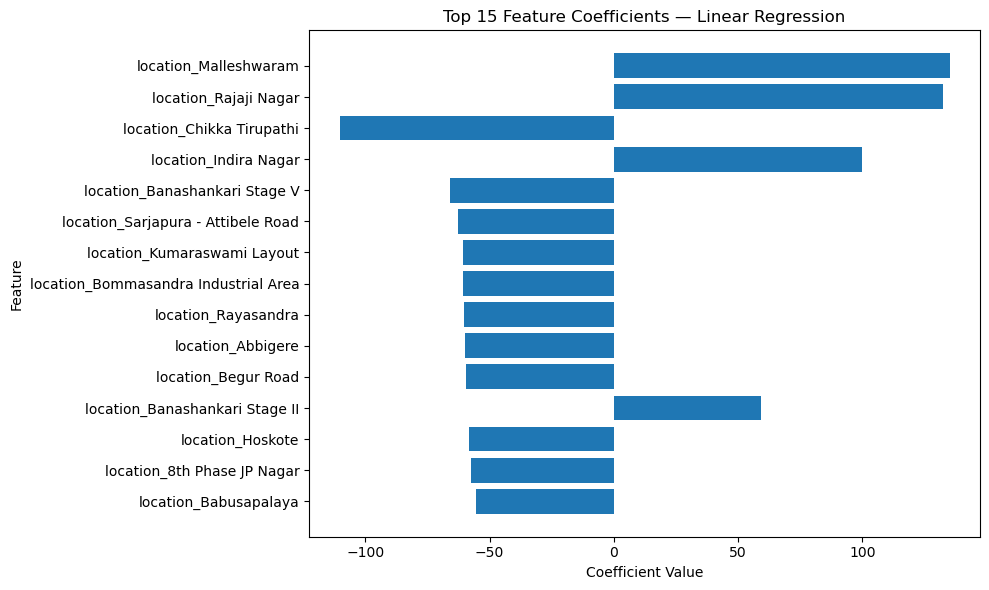

In [42]:
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Coefficients — Linear Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plots/feature_coefficients.png')
plt.show()

In [43]:
print("\n✅ Final Model Selected: Linear Regression")
print("   Reason: Best R² + Best RMSE + Interpretable + No Overfitting")




✅ Final Model Selected: Linear Regression
   Reason: Best R² + Best RMSE + Interpretable + No Overfitting


In [44]:
# Separate location and numeric coefficients
location_coef = coef_df[coef_df['Feature'].str.startswith('location_')].head(10)
numeric_coef = coef_df[~coef_df['Feature'].str.startswith('location_')]

print("Top location coefficients:")
print(location_coef)

print("\nNumeric feature coefficients:")
print(numeric_coef)

Top location coefficients:
                                  Feature  Coefficient    Abs_Coef
117                 location_Malleshwaram   135.040887  135.040887
135                 location_Rajaji Nagar   132.403411  132.403411
43              location_Chikka Tirupathi  -110.361973  110.361973
81                  location_Indira Nagar    99.686674   99.686674
26          location_Banashankari Stage V   -65.730775   65.730775
143    location_Sarjapura - Attibele Road   -62.590471   62.590471
109           location_Kumaraswami Layout   -60.830124   60.830124
37   location_Bommasandra Industrial Area   -60.698405   60.698405
138                   location_Rayasandra   -60.165343   60.165343
8                       location_Abbigere   -59.949866   59.949866

Numeric feature coefficients:
Empty DataFrame
Columns: [Feature, Coefficient, Abs_Coef]
Index: []


Part 7 — MODEL SAVING & PREDICTION


In [51]:
import pandas as pd
import pickle
import json
import os


In [52]:
os.makedirs('model', exist_ok=True)
print("✅ model folder ready")

✅ model folder ready


In [53]:
df = pd.read_csv('data/cleaned_house_prices.csv')

print("Shape of cleaned dataset:", df.shape)
df.head()

Shape of cleaned dataset: (4870, 5)


,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,1630.0,3.0,194.0,3
1,1st Block Jayanagar,1875.0,2.0,235.0,3
2,1st Block Jayanagar,1235.0,2.0,148.0,2
3,1st Block Koramangala,1415.0,2.0,110.0,2
4,1st Block Koramangala,860.0,2.0,65.5,2


In [54]:
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index

df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

print("Unique locations after grouping:", df['location'].nunique())
df['location'].value_counts().tail(10)

Unique locations after grouping: 125


location
Kodichikkanahalli            11
Margondanahalli              11
Hebbal Kempapura             11
Kaval Byrasandra             11
Old Madras Road              11
Jalahalli                    11
Ardendale                    11
Seegehalli                   11
Sarjapura - Attibele Road    11
Kumaraswami Layout           11
Name: count, dtype: int64

In [55]:
X = df.drop('price', axis=1)
y = df['price']

print("Feature columns before encoding:")
print(X.columns.tolist())

Feature columns before encoding:
['location', 'total_sqft', 'bath', 'bhk']


In [56]:
## Save Known Locations
#We save the final grouped location list so that during prediction,
#any unseen location can be mapped to 'other'.
known_locations = df['location'].unique().tolist()

with open('model/known_locations.json', 'w') as f:
    json.dump(known_locations, f)

print("✅ known_locations.json saved")
print("Total known locations:", len(known_locations))

✅ known_locations.json saved
Total known locations: 125


In [57]:
## One-Hot Encode Categorical Feature
#We convert the location column into numeric dummy columns.
X = pd.get_dummies(X, columns=['location'], drop_first=True)

print("Encoded feature shape:", X.shape)
X.head()

Encoded feature shape: (4870, 127)


,total_sqft,bath,bhk,location_5th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_Abbigere,location_Akshaya Nagar,location_Ambedkar Nagar,...,location_Uttarahalli,location_Varthur,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelahanka,location_Yelahanka New Town,location_Yeshwanthpur,location_other
0,1630.0,3.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1875.0,2.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1235.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1415.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,860.0,2.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [58]:
## Save Training Columns
#We save the exact feature column names and order used during training.
#This is important because prediction input must match the same columns.
columns = {
    'data_columns': X.columns.tolist()
}

with open('model/columns.json', 'w') as f:
    json.dump(columns, f)

print("✅ columns.json saved")
print("Total training features:", len(X.columns))

✅ columns.json saved
Total training features: 127


In [59]:
## Split Data into Train and Test Sets
#We split the data before training the final model.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3896, 127)
X_test shape : (974, 127)
y_train shape: (3896,)
y_test shape : (974,)


In [60]:
## Train Final Linear Regression Model
#We train the final model using the prepared feature set.
model = LinearRegression()
model.fit(X_train, y_train)

test_r2 = model.score(X_test, y_test)

print(f"✅ Model trained successfully")
print(f"Test R² Score: {test_r2:.4f}")

✅ Model trained successfully
Test R² Score: 0.8160


In [61]:
## Save the Trained Model
#We save the final trained model using pickle.
with open('model/house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved to model/house_price_model.pkl")

✅ Model saved to model/house_price_model.pkl


In [62]:
## Load Saved Model and Metadata
#Now we load:
#- saved model
#- saved feature columns
#- saved known locations
#This simulates the actual prediction phase.
with open('model/house_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('model/columns.json', 'r') as f:
    data_columns = json.load(f)['data_columns']

with open('model/known_locations.json', 'r') as f:
    loaded_known_locations = json.load(f)

print("✅ Model, columns, and known locations loaded successfully")
print("Total loaded columns:", len(data_columns))
print("Total loaded locations:", len(loaded_known_locations))

✅ Model, columns, and known locations loaded successfully
Total loaded columns: 127
Total loaded locations: 125


In [67]:
## Create Prediction Function
# This function:
# - accepts new user input
# - handles unseen locations
# - encodes the input
# - adds missing columns with 0
# - arranges columns in the exact training order
# - returns predicted house price
def predict_price(location, sqft, bath, bhk):
    if location not in loaded_known_locations:
        location = 'other'
    
    input_df = pd.DataFrame({
        'location': [location],
        'total_sqft': [sqft],
        'bath': [bath],
        'bhk': [bhk]
    })
    
    input_encoded = pd.get_dummies(input_df, columns=['location'], drop_first=True)
    
    input_encoded = input_encoded.reindex(columns=data_columns, fill_value=0)
    
    prediction = loaded_model.predict(input_encoded)[0]
    
    return round(prediction, 2)

In [68]:
## Test the Prediction Function
#Now we test the saved model on sample user inputs.
predicted_price_1 = predict_price('Rajaji Nagar', 2000, 3, 3)
print("Predicted Price for Rajaji Nagar property:", predicted_price_1, "Lakhs")

Predicted Price for Rajaji Nagar property: 161.39 Lakhs


In [69]:
predicted_price_2 = predict_price('Whitefield', 1200, 2, 2)
print("Predicted Price for Whitefield property:", predicted_price_2, "Lakhs")

Predicted Price for Whitefield property: 105.9 Lakhs


In [70]:
predicted_price_3 = predict_price('Some New Unknown Location', 1500, 2, 3)
print("Predicted Price for unknown location property:", predicted_price_3, "Lakhs")

Predicted Price for unknown location property: 120.96 Lakhs
